# Tarea 2 — Pregunta 2: SVD aplicado a Olivetti Faces
**IMT2230 — Álgebra Lineal Avanzada y Modelamiento**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

## Carga de datos y construcción de X

Se carga el dataset Olivetti Faces. Cada imagen es de 64×64 píxeles en escala de grises.
Se aplana a un vector de 4096 píxeles, formandola matrix $X \in \mathbb{R}^{400 \times 4096}$.

In [2]:
faces = fetch_olivetti_faces(shuffle=False)
X = faces.data          # (400, 4096), cada fila es una imagen aplanada
img_shape = (64, 64)    # dimensión original

print(f"Forma de X: {X.shape}")
print(f"n = {X.shape[0]} imágenes, d = {X.shape[1]} píxeles por imagen")

Forma de X: (400, 4096)
n = 400 imágenes, d = 4096 píxeles por imagen


## Centrado y SVD

Se centran los datos restando la imagen promedio $\bar{x}$:
$$\tilde{X} = X - \mathbf{1}\bar{x}^\top = U\Sigma V^\top$$

- $U \in \mathbb{R}^{400 \times 400}$: coordenadas de cada imagen en la nueva base
- $\Sigma$: valores singulares $\sigma_1 \geq \sigma_2 \geq \cdots$
- $V \in \mathbb{R}^{4096 \times 400}$: las eigen-imágenes (cada columna es una)

In [ ]:
x_mean = X.mean(axis=0)          # imagen promedio, shape (4096,)
X_tilde = X - x_mean             # datos centrados

U, s, Vt = np.linalg.svd(X_tilde, full_matrices=False)
# s  : valores singulares, shape (400,)
# Vt : filas = eigen-imágenes, o sea, vectores propios (400, 4096)

print(f"Valores singulares calculados: {len(s)}")
print(f"Forma de U: {U.shape}, Vt: {Vt.shape}")

Valores singulares calculados: 400
Forma de U: (400, 400), Vt: (400, 4096)


## Parte (a): Valores singulares y varianza explicada

La varianza explicada acumulada por los primeros $k$ componentes es:
$$\frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^r \sigma_i^2}$$

Componentes para explicar el 90% de la varianza: k = 66
Componentes para explicar el 99% de la varianza: k = 260


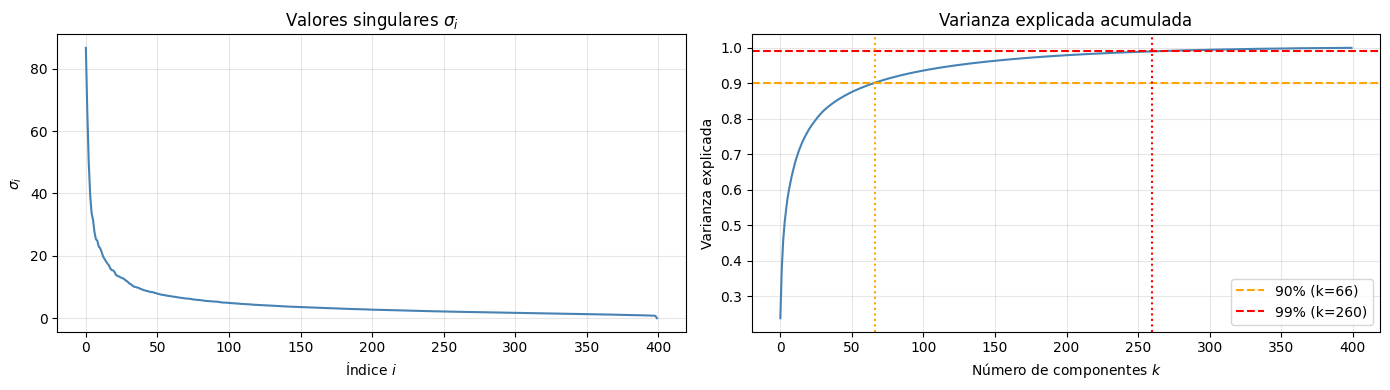

In [4]:
varianza_total = np.sum(s**2)
varianza_acumulada = np.cumsum(s**2) / varianza_total

k90 = np.searchsorted(varianza_acumulada, 0.90) + 1
k99 = np.searchsorted(varianza_acumulada, 0.99) + 1
print(f"Componentes para explicar el 90% de la varianza: k = {k90}")
print(f"Componentes para explicar el 99% de la varianza: k = {k99}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: valores singulares
axes[0].plot(s, color='steelblue')
axes[0].set_title('Valores singulares $\\sigma_i$')
axes[0].set_xlabel('Índice $i$')
axes[0].set_ylabel('$\\sigma_i$')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: varianza explicada acumulada
axes[1].plot(varianza_acumulada, color='steelblue')
axes[1].axhline(0.90, color='orange', linestyle='--', label=f'90% (k={k90})')
axes[1].axhline(0.99, color='red',    linestyle='--', label=f'99% (k={k99})')
axes[1].axvline(k90, color='orange', linestyle=':')
axes[1].axvline(k99, color='red',    linestyle=':')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Número de componentes $k$')
axes[1].set_ylabel('Varianza explicada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parte_a.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación (a):**

Los valores singulares decaen rápidamente, lo que indica que el dataset tiene una estructura de baja dimensión: la mayor parte de la varianza se concentra en pocos componentes. Con $k = $ [66] componentes se explica el 90% de la varianza, y con $k = $ [260] el 99%, lo que sugiere que las imágenes de caras viven aproximadamente en un subespacio de dimensión mucho menor que los 4096 píxeles originales.

## Parte (b): Imagen promedio y eigen-imágenes

Las eigen-imágenes son las filas de $V^\top$, reshaped a 64×64.

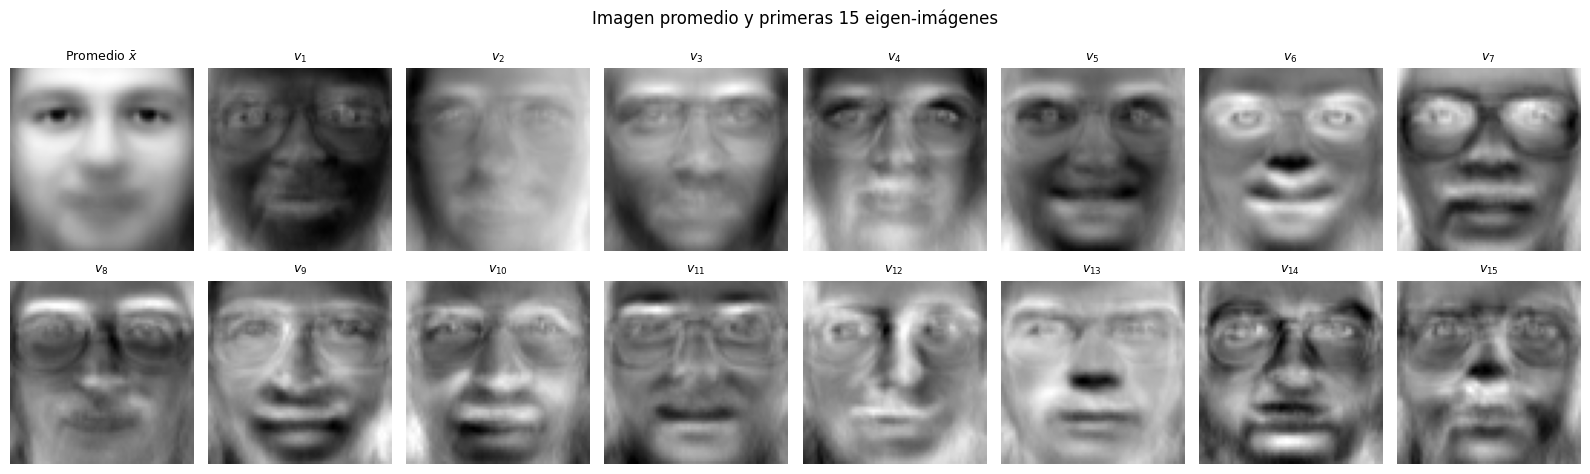

In [ ]:
n_eigen = 15  # mostramos las primeras 15 eigen-imágenes

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

# Imagen promedio
axes[0].imshow(x_mean.reshape(img_shape), cmap='gray')
axes[0].set_title('Promedio $\\bar{x}$', fontsize=9)
axes[0].axis('off')

# Eigen-imágenes
for i in range(n_eigen):
    eigen_img = Vt[i].reshape(img_shape)
    axes[i+1].imshow(eigen_img, cmap='gray')
    axes[i+1].set_title(f'$v_{{{i+1}}}$', fontsize=9)
    axes[i+1].axis('off')

plt.suptitle('Imagen promedio y primeras 15 eigen-imágenes', fontsize=12)
plt.tight_layout()
plt.savefig('parte_b.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación (b):** 

- $v_1$: Captura la variación global de iluminación (diferencia entre cara clara y oscura)
- $v_3$: Captura la silueta de los anteojos, la cual es muy marcada, junto con el contorno general de la cara (óvalo). Esto sugiere que capta la variación entre personas con anteojos vs sin anteojos, combinada con la forma general del rostro. 
- $v_5$: Captura variaciones de expresión facial, en particular la presencia de sonrisa en la zona de la boca
- $v_6$: Captura anillos muy marcados alrededor de los ojos (como anteojos de marco grueso) y una zona oscura prominente en la nariz/boca. Parece capturar específicamente la presencia de anteojos de marco grueso como un rasgo diferenciador fuerte entre individuos.


## Parte (c): Reconstrucción progresiva

Para una imagen $x$, su reconstrucción con $k$ eigen-imágenes es:
$$\hat{x}_k = \bar{x} + \sum_{i=1}^k z_i v_i, \qquad z_i = \tilde{x}^\top v_i$$

donde $\tilde{x} = x - \bar{x}$ es la imagen centrada.

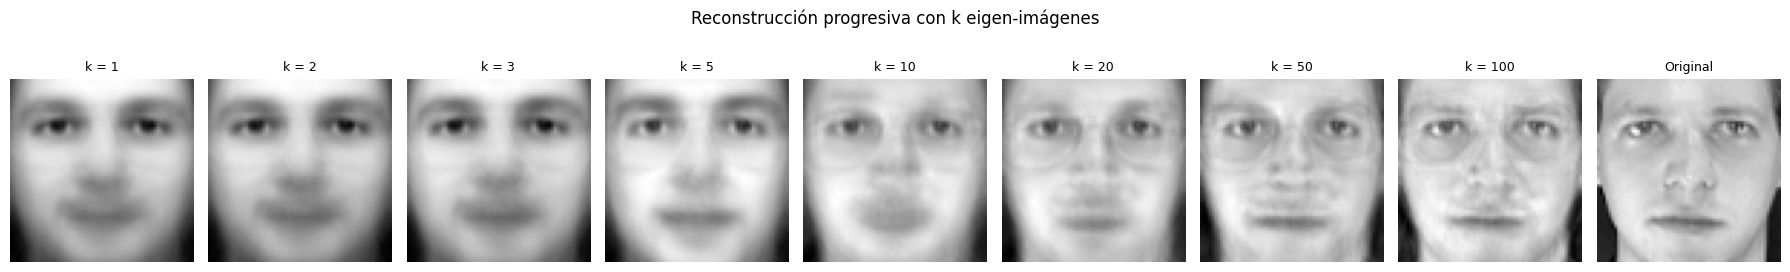

In [6]:
# Elegimos una imagen del dataset
idx = 0
x_orig = X[idx]              # imagen original
x_tilde = x_orig - x_mean   # imagen centrada

# Coordenadas z_i = x_tilde . v_i
z = Vt @ x_tilde             # shape (400,)

# Valores de k a mostrar
ks = [1, 2, 3, 5, 10, 20, 50, 100]

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(18, 3))

for j, k in enumerate(ks):
    x_recon = x_mean + (z[:k] @ Vt[:k])   # reconstrucción con k componentes
    x_recon = np.clip(x_recon, 0, 1)       # recortar a rango válido [0,1]
    axes[j].imshow(x_recon.reshape(img_shape), cmap='gray')
    axes[j].set_title(f'k = {k}', fontsize=9)
    axes[j].axis('off')

# Imagen original al final
axes[-1].imshow(x_orig.reshape(img_shape), cmap='gray')
axes[-1].set_title('Original', fontsize=9)
axes[-1].axis('off')

plt.suptitle('Reconstrucción progresiva con k eigen-imágenes', fontsize=12)
plt.tight_layout()
plt.savefig('parte_c.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación (c):** 
Con k=1 ya se reconoce la forma general de una cara, aunque muy borrosa captura principalmente la estructura promedio de iluminación y posición de rasgos. A partir de k≈5 se distinguen claramente los rasgos faciales principales (ojos, nariz, boca). Es interesante notar que recién entre k≈10–20 aparece un detalle característico de esta persona en particular (los lentes), lo que sugiere que ese rasgo no es parte de la variación "promedio" del dataset sino algo más específico. Con k≈50 reconstrucción ya es visualmente casi indistinguible de la original.